In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Mainly for progress bars
import tqdm as tqdm

from community_system_mapping import COMMUNITY_TO_SYSTEM, NON_SYMPTOMS, REPRESENTATIVE_SYMPTOMS

In [ ]:
# First load the graph since we will be using it for the research questions
G = nx.read_graphml("./NetworkFiles/network_graph_symptom.graphml")
print("Network loaded!")

In [ ]:
#-----------------------------------------------------------------------------------------------------#
# Could we determine which system of the body requires attention based solely on the symptoms present?
#-----------------------------------------------------------------------------------------------------#

In [ ]:
# This is the Louvain method.
# Using this as reference:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html
def detect_body_systems(G):
    # Detect communities using NetworkX's Louvain implementation
    communities = nx.community.louvain_communities(G)

    # This is just enumerating the communities.
    # For each community, we make the node the key and the community value, the value
    community_dict = {}
    for community, community_nodes in enumerate(communities):
        for node in community_nodes:
            community_dict[node] = community

    communities_df = pd.DataFrame({
        "node": list(community_dict.keys()),
        "communities": list(community_dict.values())
    })

    return community_dict, communities_df


In [ ]:
def calc_member_strength(G, community_dict):

    # Now, we make a list to handle each object
    node_member_strength = []

    # Now we go through EACH node
    for node in G.nodes():
        community_number = community_dict[node]
        internal_connections = 0
        external_connections = 0

        # And for each symptom, we check their neighbour.
        for neighbour in G.neighbors(node):
            edge_weight = G[node][neighbour]['weight']

            # We now check if that neighbour is in the same community.
            if community_number == community_dict[neighbour]:
                internal_connections += edge_weight

            # Otherwise,
            else:
                external_connections += edge_weight

        total_weight = internal_connections + external_connections
        # Now we calculate the ratio
        # But make sure we don't divide by 0
        if total_weight > 0:
            member_strength = internal_connections / total_weight
        else:
            member_strength = 0

        node_member_strength.append({
            "symptom": node,
            "community": community_number,
            "member_strength": member_strength,
            "internal_connections": internal_connections,
            "external_connections": external_connections,
            "total_weight": total_weight
        })

    # Easily convert to df (since its easier to use seaborn and visualizations)
    member_strength_df = pd.DataFrame(node_member_strength)

    return member_strength_df

In [ ]:
def system_identification(G, community_dict, member_strength_df):

    community_df = pd.DataFrame({
        "symptom": list(community_dict.keys()),
        "community": list(community_dict.values())
    })

    # We then count nodes in each community, finding the largest one.
    community_sizes = community_df["community"].value_counts()

    # Now we want to get the top communities, let's say 10 for now?
    top_communities_by_size = community_sizes.nlargest(10)

    print(top_communities_by_size)

    # Now, we can get the top symptoms of those top communities.
    # We calculated the membership strength earlier
    meaningful_communities = {}

    for community_number in top_communities_by_size.index:
        symptoms_of_community = member_strength_df[member_strength_df["community"] == community_number]

        # Only going to get the top symptoms
        # For one of the communitites, there are like 1400 symptoms
        top_symptoms = symptoms_of_community.nlargest(20, "member_strength")

        meaningful_communities[community_number] = {
            "top_symptoms": top_symptoms["symptom"].to_list(),
            "size": top_communities_by_size[community_number]
        }

    return community_df, meaningful_communities


In [112]:
def filtered_and_add_system(member_strength_df):

    # First, we filter out the non-symptoms
    # https://stackoverflow.com/questions/19960077/how-to-filter-pandas-dataframe-using-in-and-not-in-like-in-sql
    # Using ~, negates the boolean
    valid_symptoms = ~member_strength_df["symptom"].isin(NON_SYMPTOMS)
    filtered_df = member_strength_df[valid_symptoms].copy()

    #  Then we can add the body system label
    # I get a warning if I don't use loc
    filtered_df.loc[:, "body_system"] = filtered_df["community"].map(COMMUNITY_TO_SYSTEM)

    # Create a dictionary mapping symptoms to their systems
    # THIS IS FOR REPRESENTATIVE SYMPTOMS.
    # I went through this manually out of the top 20 symptoms.
    rep_symptom_to_system = {}
    for system, symptoms in REPRESENTATIVE_SYMPTOMS.items():
        for symptom in symptoms:
            rep_symptom_to_system[symptom] = system

    # For any symptom in REPRESENTATIVE_SYMPTOMS, we set the community.
    for symptom in filtered_df["symptom"]:
        if symptom in rep_symptom_to_system:
            filtered_df.loc[filtered_df["symptom"] == symptom, "body_system"] = rep_symptom_to_system[symptom]

    # So everything is dropped if body_system is empty.
    body_system_mask = filtered_df["body_system"].notna()
    labeled_system = filtered_df[body_system_mask].copy()

    return labeled_system

In [124]:
def create_body_system_visualizations(labeled_system):

    plt.figure(figsize=(12, 6))
    system_counts = labeled_system['body_system'].value_counts()

    # Interesting thing in seaborn...
    # passing pallete without assigning hue is deprecated.
    # Need to set hue to y, while also disabling the legend to False
    ax = sns.barplot(
        y=system_counts.index,
        x=system_counts.values,
        hue=system_counts.index,
        palette='viridis',
        orient='h',
        legend=False
    )

    for i, v in enumerate(system_counts.values):
        ax.text(v + 5, i, f"{v}", va='center')

    plt.title('Distribution of Symptoms Across Body Systems', fontsize=16)
    plt.xlabel('Number of Symptoms', fontsize=12)
    plt.ylabel('Body System', fontsize=12)
    plt.tight_layout()
    plt.savefig('system_size_distribution.png', dpi=300, bbox_inches='tight')


In [ ]:
community_dict, communities_df = detect_body_systems(G)

In [90]:
member_strength_df = calc_member_strength(G, community_dict)

In [91]:
community_df, meaningful_communities = system_identification(G, community_dict, member_strength_df)

community
1     1579
9     1531
55    1516
0     1288
2      973
4      853
34     617
48      20
5       17
15      11
Name: count, dtype: int64

Top symptoms in Community 1:
- chronic fever (membership strength: 1.00)
- teeth appear yellow (membership strength: 1.00)
- painful arc sign (membership strength: 1.00)
- eccentric swelling (membership strength: 1.00)
- underdeveloped musculature of the scapular belt (membership strength: 1.00)
- history of finger trauma or sprain (membership strength: 1.00)
- difficulty moving the lower limbs (membership strength: 1.00)
- positive shoulder overlap test (membership strength: 1.00)
- dental plaque (membership strength: 1.00)
- tartar (membership strength: 1.00)
- lateral neck (membership strength: 1.00)
- nipple bleeding (membership strength: 1.00)
- absence of menarche post-puberty (membership strength: 1.00)
- fibrocystic breast changes (membership strength: 1.00)
- increased distance between the first (membership strength: 1.00)
- second 

In [113]:
labeled_system = filtered_and_add_system(member_strength_df)

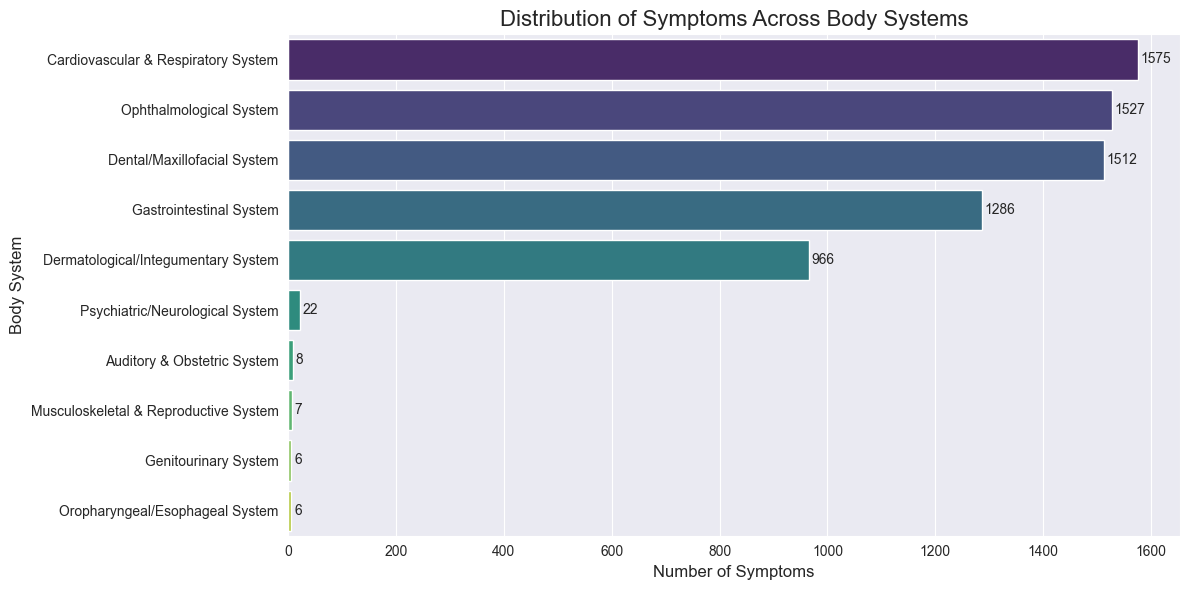

In [125]:
create_body_system_visualizations(labeled_system)